# Personality Type Classifier - Data Preprocessing

This notebook covers data exploration, cleaning, and preprocessing 
of the raw personality dataset to prepare it for model training.

**Dataset:** personality_dataset.csv  
**Author:** Duwarahavidyan J.     
**Date:** 2026-05-07

### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### 2. Load Dataset

In [2]:
df = pd.read_csv("../dataset/personality_dataset.csv")

### 3. Exploratory Data Analysis (EDA)

In [3]:
# Inspect the first few rows.

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
# Shape of the dataset

df.shape

(2900, 8)

In [5]:
# Summary of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [6]:
# Check duplicate rows

df.duplicated().sum()

388

In [7]:
# Check for missing values

df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

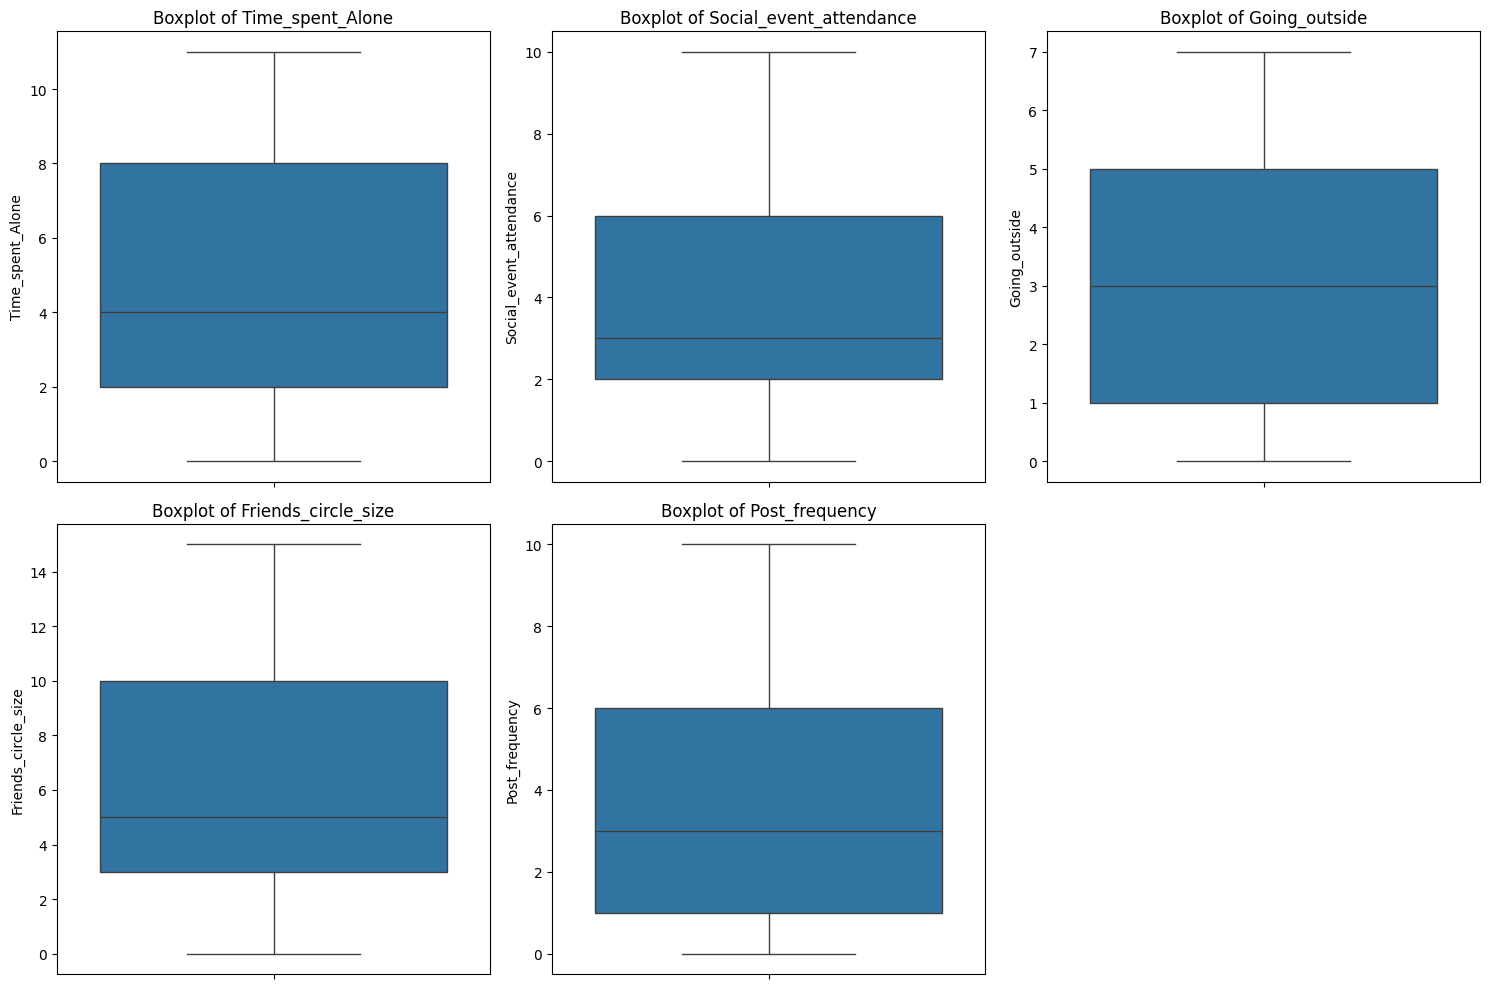

In [8]:
# Checking for outliers

# Numerical columns
numerical_cols = [
    'Time_spent_Alone',
    'Social_event_attendance',
    'Going_outside',
    'Friends_circle_size',
    'Post_frequency'
]

# Plot boxplots
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [9]:
# Count of the target variable

df['Personality'].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

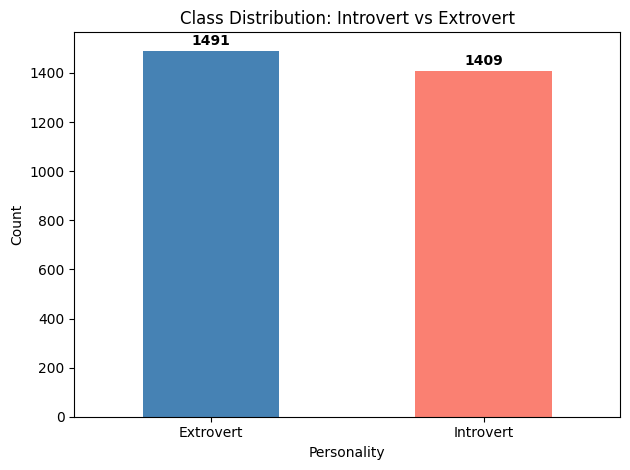

In [10]:
# Visualise target distribution

counts = df['Personality'].value_counts()
ax = counts.plot(kind='bar', color=['steelblue', 'salmon'])

for i, count in enumerate(counts):
    ax.text(i, count + 10, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Class Distribution: Introvert vs Extrovert')
plt.xlabel('Personality')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4. Data Preprocessing

##### Remove Duplicates

In [11]:
# Remove Duplicate Records

df = df.drop_duplicates()

df.duplicated().sum()


0

In [12]:
# Shape of the dataset after removing duplicates

df.shape

(2512, 8)

##### Encoding Categorical Variables

Machine learning algorithms require numerical input data. Therefore, categorical variables are must converted into numerical values.

In [13]:
# Encoding the categorical variables

le = LabelEncoder()

df['Personality'] = le.fit_transform(df['Personality'])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Since we have null values we map following features rather than using a encoder

cat_cols = ['Stage_fear', 'Drained_after_socializing']

for col in cat_cols:
    df[col] = df[col].map({'No': 0, 'Yes': 1})



Label mapping: {'Extrovert': 0, 'Introvert': 1}


In [14]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,0
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,1
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,1
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,0
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,0


##### Split the Dataset

Here we split the dataset beforehand to avoid **data leakage**.

In [15]:
# Split the dataset into train and test

X = df.drop("Personality", axis=1) # Features
y = df["Personality"] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 2009 rows | Test: 503 rows



Our dataset has missing values across several columns. Since we are working with a small dataset (~2477 rows), dropping rows with nulls would result in unnecessary data loss. So we impute instead.

- **Numerical columns** ---> impute with **median**  
  Since our dataset has no significant outliers, both mean and median are valid choices. We use median as it is slightly more robust to any skewness in the distribution.

- **Categorical columns** (`Stage_fear`, `Drained_after_socializing`) 
  → impute with **mode** (most frequent value)

##### Handling Missing Values

In [16]:
print(f"Missing values in Train: \n{X_train.isnull().sum()}\n\nMissing values in Test: \n{X_test.isnull().sum()}")

Missing values in Train: 
Time_spent_Alone             50
Stage_fear                   60
Social_event_attendance      49
Going_outside                53
Drained_after_socializing    42
Friends_circle_size          57
Post_frequency               52
dtype: int64

Missing values in Test: 
Time_spent_Alone             11
Stage_fear                   13
Social_event_attendance      12
Going_outside                12
Drained_after_socializing     9
Friends_circle_size          18
Post_frequency               11
dtype: int64


In [17]:
# Numerical imputer - median
num_imputer = SimpleImputer(strategy='median')

# Categorical imputer - most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')

cat_cols = ['Stage_fear', 'Drained_after_socializing']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Fit on X_train, transform both
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

print(f"Missing values in Train: \n{X_train.isnull().sum()}\n\nMissing values in Test: \n{X_test.isnull().sum()}")

Missing values in Train: 
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64

Missing values in Test: 
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64


In [18]:
X_train.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
1394,1.0,0.0,6.0,5.0,0.0,14.0,3.0
2064,11.0,1.0,0.0,2.0,1.0,3.0,0.0
1585,1.0,0.0,7.0,6.0,0.0,6.0,8.0
375,0.0,0.0,6.0,5.0,0.0,5.0,5.0
2784,1.0,0.0,8.0,3.0,0.0,12.0,9.0


In [19]:
# Count of the target variable on train data set

y_train.value_counts()

Personality
0    1133
1     876
Name: count, dtype: int64

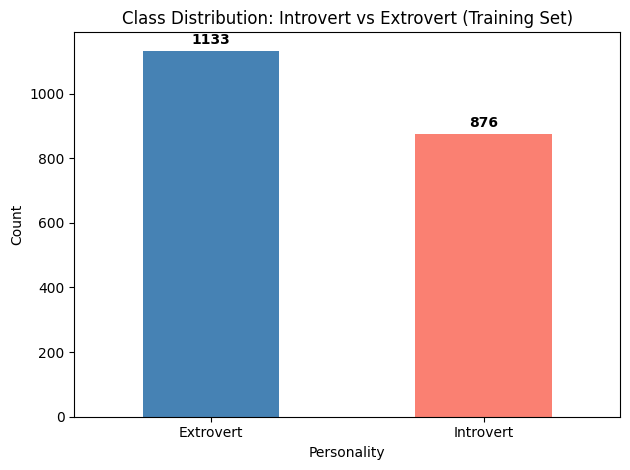

In [20]:
# Visualise target distribution on training set

counts = pd.Series(y_train).value_counts()
ax = counts.plot(kind='bar', color=['steelblue', 'salmon'])

for i, count in enumerate(counts):
    ax.text(i, count + 10, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Class Distribution: Introvert vs Extrovert (Training Set)')
plt.xlabel('Personality')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=le.classes_, rotation=0)
plt.tight_layout()
plt.show()

Here we don't need to balance the dataset as the class ratio is approximately 56/44, mild enough that `class_weight='balanced'` in our models is sufficient to handle it.

##### Feature Scaling

Feature scaling is applied for Logistic Regression as linear models are sensitive to feature magnitudes. Features on larger scales can disproportionately influence the model. Tree-based models such as Random Forest and Gradient Boosting are unaffected by scaling since they split on thresholds rather than distances.

In [21]:
from sklearn.discriminant_analysis import StandardScaler
# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

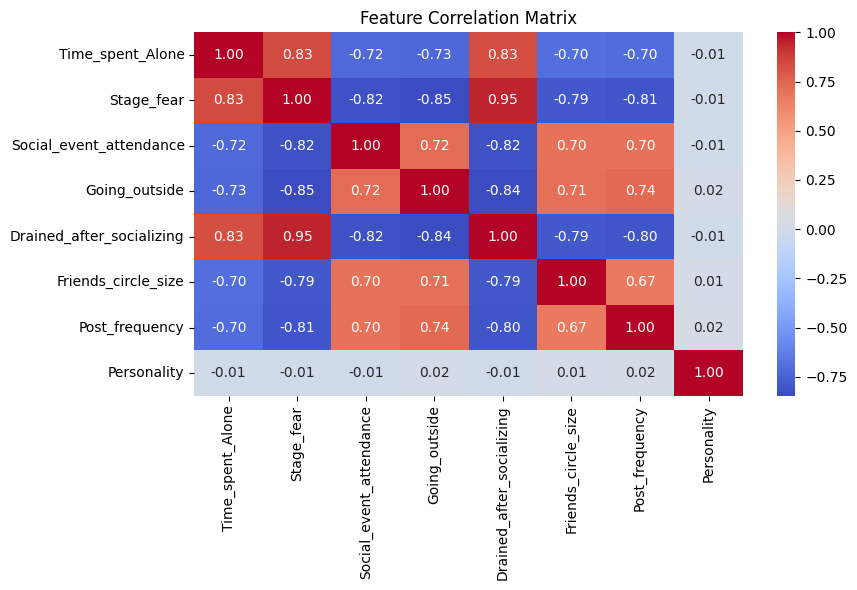

In [27]:
plt.figure(figsize=(9, 6))
corr = X_train_scaled.join(pd.Series(y_train, name='Personality')).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

According to above heatmap `Stage_fear` and `Drained_after_socializing` show high multicollinearity (0.95). This may slightly affect Logistic Regression but tree-based models are unaffected. All features are retained as each contributes meaningful signal to the target variable.

In [23]:
# Combine and save train and test datasets
train = X_train.copy()
train['Personality'] = y_train

test = X_test.copy()
test['Personality'] = y_test

train.to_csv('../dataset/train_processed.csv', index=False)
test.to_csv('../dataset/test_processed.csv', index=False)


In [29]:
# Combine and save train and test scaled datasets
train_scaled = X_train_scaled.copy()
train_scaled['Personality'] = y_train.values

test_scaled = X_test_scaled.copy()
test_scaled['Personality'] = y_test.values

train_scaled.to_csv('../dataset/train_processed_scaled.csv', index=False)
test_scaled.to_csv('../dataset/test_processed_scaled.csv', index=False)

In [ ]:
# Save the label encoder
joblib.dump(le, '../artifacts/label_encoder.pkl')
joblib.dump(scaler, '../artifacts/scaler.pkl')
joblib.dump(num_imputer, '../artifacts/num_imputer.pkl')
joblib.dump(cat_imputer, '../artifacts/cat_imputer.pkl')

['../artifacts/cat_imputer.pkl']

In [1]:
import sklearn
print(sklearn.__version__)

1.5.0
